# Computer Exercise 15.32 — Problem 3
## 프로토콜 자체를 검정한다 — A/A 보정 · 블록 간 재현 · 판정 안정성 $n^\dagger$

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.32
> **단원**: Ch 15 Sequential Decision Making — §15.32 Fixed-Protocol Re-adjudication
> **풀이 일자**: 2026-08-17 (Day 99)
> **언어**: Python 3.10 · NumPy / pandas / Matplotlib
>
> Problem 1 과 2 는 오늘 고정한 프로토콜을 **사용**했다. Problem 3 은 그 프로토콜을 **검정**한다.
> 이유가 생겼기 때문이다: 같은 비교 `cnrt` $-$ `fix_small` 이
> P1 의 시드 블록 (99101–99120) 에서는 $+0.1253$, CI $[+0.052,+0.203]$, Holm 후 **유의**였는데
> P2 의 독립 블록 (99201–99220) 에서는 $+0.0319$, CI $[-0.062,+0.124]$, **유의하지 않았다**.
>
> 두 블록 모두 $n=20$ 이고 프로토콜도 동일하다. 그렇다면 Day 98 이 정한 $n=20$ 은
> **무엇을 보장하고 무엇을 보장하지 않는가?** Day 98 은 $n=20$ 을 *부호 오류율 0 %* 라는
> 기준으로 골랐다. 부호가 안정한 것과 **판정(유의/비유의)이 안정한 것은 다른 요구**다.

## 1. 문제 (원문)

> **Computer Exercise 15.32.3.** Validate the fixed protocol of Exercise 15.32.1 rather than
> applying it. Train a pool of $60$ common seeds for four arms (`base`, `cnrt`, `fix_small`,
> `fix_big`) at $T = 10\,000$. (a) Estimate the empirical type-I error of the decision rule
> "reject when the $95\%$ bootstrap interval excludes zero" under two null constructions: an
> *unpaired null* (two disjoint seed groups drawn from the same arm) and a *deployment-only null*
> (identical learners evaluated under two independent deployment streams). Compare the family-wise
> error rate of three simultaneous null comparisons with and without Holm correction.
> (b) Partition the pool into three disjoint blocks of $20$ and report whether the verdicts for the
> key comparisons agree across blocks. (c) For each key comparison, estimate the *sign-error rate*
> and the *verdict-agreement rate* as a function of subsample size $n$, and define
> $n^\dagger = \min\{n : \text{verdict agreement} \ge 0.90\}$. (d) Adjudicate the outstanding claims
> of §15.23–§15.31 under the validated protocol and assign evidence grades.

### 한국어 풀이용 정리

프로토콜의 세 가지 성질을 각각 다른 방법으로 잰다.

| 성질 | 질문 | 방법 | 기준 |
|---|---|---|---|
| **보정 (calibration)** | 차이가 없을 때 없다고 하는가? | A/A 검정 2 종 | 1 종 오류 $\approx \alpha = 0.05$ |
| **다중성 (multiplicity)** | 3 개 비교에서 FWER 이 커지는가? | 무보정 대 Holm | FWER $\le 0.05$ |
| **재현 (replication)** | 다른 시드 블록에서 같은 판정이 나오는가? | 3 개 독립 블록 | 3/3 일치 |
| **분해능 (resolution)** | 판정이 안정되려면 몇 시드가 필요한가? | 부분표본 재추출 | 일치율 $\ge 0.90$ 인 $n^\dagger$ |

**부호 안정성 $n^\star$ 와 판정 안정성 $n^\dagger$ 의 구분**이 이 문제의 핵심이다.
Day 98 은 전자로 $n=20$ 을 정했고, P1·P2 의 불일치는 후자가 더 큰 값을 요구함을 시사한다.

## 2. 수학적 배경

### 2.1 두 가지 귀무 구성

프로토콜의 1 종 오류를 재려면 **참으로 차이가 없는** 두 arm 이 필요하다. 같은 arm 을 두 번 쓰되
짝짓는 방식을 달리해 두 종류의 귀무를 만든다.

**(N1) 비짝지음 귀무 (unpaired null).** 60 개 `base` 실행을 무작위로 두 그룹
$G_1, G_2$ ($|G_1|=|G_2|=20$) 로 나누고 인덱스 순으로 짝지어 $d_i = R_{G_1(i)} - R_{G_2(i)}$.
초기화 분산이 상쇄되지 않으므로 **분산이 가장 큰** 귀무다.

**(N2) 배포 전용 귀무 (deployment-only null).** *같은* 학습기를 서로 독립인 두 배포 난수열로
평가해 $d_i = R(\ell_i; u_i) - R(\ell_i; u_i')$. 학습 분산이 완전히 상쇄되므로
**분산이 가장 작은** 귀무다.

실제 arm 간 비교의 분산은 이 둘 사이에 있다. 두 극단에서 모두 1 종 오류가
$\alpha$ 근처면 규칙이 보정되어 있다고 말할 수 있다.

$$\widehat{\text{type-I}} = \frac1M \sum_{m=1}^{M}
\mathbf 1\!\left[\,0 \notin \text{CI}^{(m)}_{95\%}\,\right]$$

### 2.2 FWER 과 Holm

$m$ 개의 참인 귀무를 동시에 검정할 때 무보정 FWER 은 $1-(1-\alpha)^m$ 로 커진다
($m=3$ 이면 $0.143$). Holm 은 임의의 종속 구조에서도

$$\Pr[\text{하나 이상 오기각}] \le \alpha$$

를 보장한다. 이것을 시뮬레이션으로 확인한다 (지난 29 일 동안 한 번도 하지 않은 절차).

### 2.3 부호 안정성 $n^\star$ 대 판정 안정성 $n^\dagger$

전체 $N=60$ 시드의 짝지은 차 $\{d_i\}$ 에서 크기 $n$ 의 부분표본 $S$ 를 뽑아,

$$\text{부호 오류율}(n) = \Pr_S\!\left[\operatorname{sgn}(\bar d_S) \ne \operatorname{sgn}(\bar d_{\text{full}})\right],$$
$$\text{판정 일치율}(n) = \Pr_S\!\left[\text{판정}(S) = \text{판정}(\text{full})\right],\qquad
\text{판정} \in \{\text{유의}^+,\ \text{비유의},\ \text{유의}^-\}$$

를 추정한다. 부호 오류율은 **방향** 만 보므로 "차이 없음" 을 "있음" 으로 읽는 오류를 못 잡는다.
판정 일치율은 세 값 판정이므로 **1 종 · 2 종 오류를 모두** 센다. 따라서 항상

$$\boxed{\;n^\dagger \;\ge\; n^\star\;}$$

이고, Day 98 이 $n^\star$ 로 고른 $20$ 은 $n^\dagger$ 의 하한일 뿐이다.

### 2.4 계산 대체와 그 검증

부분표본 하나마다 $B=20\,000$ bootstrap 을 돌리면 $10^5$ 개 부분표본 $\times$ 3 비교에서
비용이 감당되지 않는다. 그래서 부분표본 연구에서는 **짝지은 $t$ 규칙**

$$\text{reject} \iff |\bar d_S| > t_{0.975,\,n-1}\, \widehat{\mathrm{sd}}(d_S)/\sqrt n$$

을 대체 규칙으로 쓴다. 대체가 정당한지는 무작위 부분표본 $500$ 개에서 **bootstrap 규칙과의
일치율**을 직접 재어 보고한다 (대체 규칙을 검증 없이 쓰는 것이야말로 Day 98 이 지적한 종류의
문제이므로).

## 3. 풀이 흐름

1. **시드 풀 확보** — 새 시드 $\{99401,\dots,99460\}$ (60 개) 로 네 arm (`base`, `cnrt`,
   `fix_small`, `fix_big`) 을 $T=10^4$ 에서 학습. P1·P2 의 시드와 겹치지 않는 **독립 풀**이다.
2. **(a) A/A 보정** — N1 (비짝지음) 과 N2 (배포 전용) 각각 $M=1000$ 회 반복해
   bootstrap CI 규칙과 부호뒤집기 규칙의 1 종 오류를 추정.
3. **(a') FWER** — 각 반복에서 서로 독립인 3 개의 귀무 비교를 만들고, 무보정과 Holm 의
   "하나 이상 기각" 비율을 비교.
4. **(b) 블록 간 재현** — 풀을 20 씩 세 블록으로 나누고 세 핵심 비교
   (`cnrt`$-$`base`, `fix_big`$-$`cnrt`, `fix_big`$-$`base`) 의 판정이 3 블록에서 일치하는지 확인.
5. **(c) 분해능** — 60 시드 전체를 기준 판정으로 두고 $n \in \{3,5,10,20,30,40\}$ 부분표본에서
   부호 오류율과 판정 일치율을 추정, $n^\dagger$ 산출. 대체 규칙의 타당성도 함께 검증.
6. **(d) 판정과 등급** — §15.23–§15.31 의 미결 주장을 오늘의 증거로 판정하고,
   Day 98 의 등급 기준으로 **Day 99 자신** 을 채점한다.
7. 갱신된 프로토콜 상수를 Day 100 용으로 JSON 에 기록.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # 그림을 셀 출력에 내장
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–98 과 동일한 5-상태 chain MDP 재구성) ───────────
NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL, SIGMA0 = 0.95, 0.05, 16, 0.25, 0.5
SIG_INIT = SIGMA0 / np.sqrt(H)          # 0.125 — Noisy 헤드 σ 의 초기값

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a                      # slip
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

# ── arm 사양: (잡음으로 탐색?, σ 를 학습?, 잡음을 주입?) ──────────────────
#   base   : 결정적 헤드 + eps-greedy                      (Day 90–98 의 baseline)
#   cnrt   : Factorized Noisy Linear, σ 학습, 잡음 탐색    (Day 90–98 의 +CNRT)
#   fixed  : 같은 잡음 탐색, 단 σ 는 초기값에 동결          (★ 통제군 1)
#   inert  : Noisy 파라미터화를 갖되 ε_W ≡ 0 + eps-greedy  (★ 통제군 2, 용량 대조)
ARM_SPEC = {           # explore_noise, learn_sigma, inject_noise
    "base":  (False, False, False),
    "cnrt":  (True,  True,  True),
    "fixed": (True,  False, True),
    "inert": (False, False, False),
}

class Learner:
    """Trunk MLP (tanh, H=16) + linear head. Noisy 헤드는 (mu, sigma) 로 분해."""
    def __init__(self, rng, arm="base", sigma_decay=0.0, anneal=False, h=H, sigma_init=None):
        self.h, self.arm = h, arm
        sigma_init = SIG_INIT if sigma_init is None else sigma_init
        self.explore_noise, self.learn_sigma, self.inject = ARM_SPEC[arm]
        self.sigma_decay, self.anneal, self.scale = sigma_decay, anneal, 1.0
        # 초기화 난수 소비 순서는 arm 과 무관 -> 모든 arm 이 같은 초기 가중치
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        self.Ws = np.full((NA, h), sigma_init)        # sigma (모든 arm 이 보유)
        self.bs = np.full(NA, sigma_init)
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def resample(self, rng):
        if not self.inject: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))   # factorized noise
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        use = noise and self.inject
        W = self.W2 + (self.Ws * self.scale * self.eps_W if use else 0.0)
        b = self.b2 + (self.bs * self.scale * self.eps_b if use else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.learn_sigma:                      # sigma 에도 TD 기울기 + (선택) weight decay
            self.Ws -= ETA * (gW2 * self.eps_W * self.scale + self.sigma_decay * self.Ws)
            self.bs -= ETA * (gb2 * self.eps_b * self.scale + self.sigma_decay * self.bs)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)

def train(seed, T, arm="base", p_train=0.20, eps_greedy=0.10, sigma_decay=0.0, anneal=False,
          sigma_init=None, trace_every=None):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, arm=arm, sigma_decay=sigma_decay, anneal=anneal, sigma_init=sigma_init)
    lr.trace = []            # (t, mean sigma) — trace_every 가 주어진 경우에만 기록
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if lr.anneal: lr.scale = 1.0 - t / T          # 선형 감쇠 스케줄
        if lr.explore_noise:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
        if trace_every and t % trace_every == 0:
            lr.trace.append((t, float(lr.Ws.mean())))
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    """freeze -> greedy 배포. 스텝당 평균 보상."""
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

# ── Day 99 고정 프로토콜 상수 (Day 98 의 실측에서 그대로 가져옴) ──────────
T_FIXED   = 10_000        # Day 98 P1: 비교가 의미를 갖는 하한 T*
N_SEEDS   = 20            # Day 98 P3: 3-시드 부호 오류율 13.6% -> n=20 에서 0%
P_DEPLOY, N_EP, PI_STAR = 0.20, 40, (1, 1, 1, 1, 1)
B_BOOT    = 20_000
ALPHA     = 0.05

# ── 프로토콜 유틸: bootstrap CI · 부호뒤집기 순열검정 · Holm · 검정력 ─────
def boot_ci(d, B=B_BOOT, seed=0, alpha=ALPHA):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(B, len(d)))
    return tuple(np.percentile(d[idx].mean(axis=1), [100*alpha/2, 100*(1-alpha/2)]))

def signflip_p(d, B=B_BOOT, seed=1):
    """짝지은 표본의 부호뒤집기(순열) 검정 — 정규성 가정 없음."""
    rng = np.random.default_rng(seed)
    obs = abs(d.mean())
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    null = np.abs((sg * d).mean(axis=1))
    return (1 + (null >= obs - 1e-15).sum()) / (B + 1)

def holm(pvals, alpha=ALPHA):
    """Holm–Bonferroni. 반환: (보정 p, 기각 여부) — 원래 순서."""
    m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * pvals[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

def n_star(d, power_c=2.8):
    m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((power_c * s / m) ** 2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z*z/n
    c = (p + z*z/(2*n)) / den
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return (max(0.0, c-hw), min(1.0, c+hw))

print(f"chain MDP: states={NS} actions={NA} ep_len={L} | gamma={GAMMA} lr={ETA} H={H} lure={R_LOCAL}")
print(f"고정 프로토콜: T={T_FIXED}  seeds={N_SEEDS}  bootstrap B={B_BOOT}  alpha={ALPHA}  다중검정=Holm")
print(f"sigma 초기값 = {SIG_INIT:.4f}")


chain MDP: states=5 actions=2 ep_len=20 | gamma=0.95 lr=0.05 H=16 lure=0.25
고정 프로토콜: T=10000  seeds=20  bootstrap B=20000  alpha=0.05  다중검정=Holm
sigma 초기값 = 0.1250


In [2]:
# ── [1] 독립 시드 풀 60 개 x 네 arm ──────────────────────────────────────
import time
POOL = list(range(99401, 99461))          # 60 시드 — P1(99101~) P2(99201~) 와 겹치지 않음
N_POOL = len(POOL)
ARMS = {"base": dict(arm="base"), "cnrt": dict(arm="cnrt"),
        "fix_small": dict(arm="fixed", sigma_init=SIG_INIT),
        "fix_big": dict(arm="fixed", sigma_init=0.55)}

t0 = time.time(); pool = {}
for name, cfg in ARMS.items():
    ls = [train(s, T_FIXED, **cfg) for s in POOL]
    R  = np.array([deploy(l, P_DEPLOY, N_EP, 9400 + i) for i, l in enumerate(ls)])   # 공통난수 u
    R2 = np.array([deploy(l, P_DEPLOY, N_EP, 60400 + i) for i, l in enumerate(ls)])  # 독립 난수 u'
    pool[name] = dict(R=R, R2=R2, rec=np.array([greedy_policy(l) == PI_STAR for l in ls]))
    print(f"  {name:>9s}: R={R.mean():+.4f} ± {R.std(ddof=1):.4f}   rho={pool[name]['rec'].mean():.2f}")
print(f"\n총 학습 {len(ARMS)*N_POOL} 회 x T={T_FIXED}  ({time.time()-t0:.1f} s)")

KEY = [("cnrt", "base"), ("fix_big", "cnrt"), ("fix_big", "base")]
full = {k: pool[k[0]]["R"] - pool[k[1]]["R"] for k in KEY}
print("\n60 시드 전체 기준 판정 (이후 모든 부분표본은 이 판정과 비교된다):")
for k in KEY:
    d = full[k]; lo, hi = boot_ci(d, seed=7)
    print(f"  {k[0]:>8s} - {k[1]:<9s}: d={d.mean():+.4f}  CI[{lo:+.4f},{hi:+.4f}]  "
          f"sd={d.std(ddof=1):.4f}  -> {'유의' if (lo>0 or hi<0) else '비유의'}")

       base: R=+0.5330 ± 0.1284   rho=0.83


       cnrt: R=+0.4006 ± 0.1894   rho=0.48


  fix_small: R=+0.3863 ± 0.1915   rho=0.45


    fix_big: R=+0.5816 ± 0.0389   rho=0.98

총 학습 240 회 x T=10000  (77.9 s)

60 시드 전체 기준 판정 (이후 모든 부분표본은 이 판정과 비교된다):
      cnrt - base     : d=-0.1324  CI[-0.1914,-0.0722]  sd=0.2353  -> 유의
   fix_big - cnrt     : d=+0.1810  CI[+0.1334,+0.2289]  sd=0.1877  -> 유의
   fix_big - base     : d=+0.0487  CI[+0.0179,+0.0827]  sd=0.1303  -> 유의


In [3]:
# ── [2] (a) A/A 보정: 두 가지 귀무에서의 1종 오류 ────────────────────────
M_AA, B_AA, N_BLK = 1000, 1500, 20
rng0 = np.random.default_rng(2026)

def rule_ci(d, B=B_AA, rng=None):
    idx = rng.integers(0, len(d), size=(B, len(d)))
    lo, hi = np.percentile(d[idx].mean(axis=1), [2.5, 97.5])
    return (lo > 0) or (hi < 0)

def rule_flip(d, B=B_AA, rng=None):
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    p = (1 + (np.abs((sg * d).mean(axis=1)) >= abs(d.mean()) - 1e-15).sum()) / (B + 1)
    return p <= ALPHA, p

Rb = pool["base"]["R"]; Rb2 = pool["base"]["R2"]
fp = {"N1_ci": 0, "N1_flip": 0, "N2_ci": 0, "N2_flip": 0}
fwer_raw = fwer_holm = 0
for m in range(M_AA):
    perm = rng0.permutation(N_POOL)
    d1 = Rb[perm[:N_BLK]] - Rb[perm[N_BLK:2*N_BLK]]              # N1 비짝지음 귀무
    sel = rng0.choice(N_POOL, N_BLK, replace=False)
    d2 = Rb[sel] - Rb2[sel]                                      # N2 배포 전용 귀무
    fp["N1_ci"]   += rule_ci(d1, rng=rng0)
    fp["N2_ci"]   += rule_ci(d2, rng=rng0)
    fp["N1_flip"] += rule_flip(d1, rng=rng0)[0]
    fp["N2_flip"] += rule_flip(d2, rng=rng0)[0]
    ps = []                                                      # m=3 동시 귀무 -> FWER
    for _ in range(3):
        pm = rng0.permutation(N_POOL)
        ps.append(rule_flip(Rb[pm[:N_BLK]] - Rb[pm[N_BLK:2*N_BLK]], rng=rng0)[1])
    ps = np.array(ps)
    fwer_raw  += bool((ps <= ALPHA).any())
    fwer_holm += bool(holm(ps)[1].any())

aa = pd.DataFrame([
    dict(귀무="N1 비짝지음 (두 그룹, 초기화 분산 상쇄 안 됨)", 규칙="bootstrap CI",
         type_I=fp["N1_ci"]/M_AA),
    dict(귀무="N1 비짝지음", 규칙="부호뒤집기 p", type_I=fp["N1_flip"]/M_AA),
    dict(귀무="N2 배포 전용 (같은 학습기, 다른 배포 난수)", 규칙="bootstrap CI",
         type_I=fp["N2_ci"]/M_AA),
    dict(귀무="N2 배포 전용", 규칙="부호뒤집기 p", type_I=fp["N2_flip"]/M_AA),
])
se = np.sqrt(0.05 * 0.95 / M_AA)
print(f"표 1 — A/A 1종 오류 (M={M_AA} 반복, 목표 alpha={ALPHA}, MC 표준오차 ±{1.96*se:.3f})")
print(aa.to_string(index=False))
print(f"\n표 2 — FWER (m=3 동시 귀무, M={M_AA})")
print(f"  무보정 : {fwer_raw/M_AA:.3f}   (이론 예측 1-(1-a)^3 = {1-(1-ALPHA)**3:.3f})")
print(f"  Holm   : {fwer_holm/M_AA:.3f}   (보장 <= {ALPHA})")
print(f"  => Holm 이 막아 준 오기각: {(fwer_raw-fwer_holm)/M_AA:.3f} (반복 {fwer_raw-fwer_holm} 회)")

표 1 — A/A 1종 오류 (M=1000 반복, 목표 alpha=0.05, MC 표준오차 ±0.014)
                           귀무           규칙  type_I
N1 비짝지음 (두 그룹, 초기화 분산 상쇄 안 됨) bootstrap CI  0.0940
                      N1 비짝지음      부호뒤집기 p  0.0550
  N2 배포 전용 (같은 학습기, 다른 배포 난수) bootstrap CI  0.0640
                     N2 배포 전용      부호뒤집기 p  0.0450

표 2 — FWER (m=3 동시 귀무, M=1000)
  무보정 : 0.146   (이론 예측 1-(1-a)^3 = 0.143)
  Holm   : 0.053   (보장 <= 0.05)
  => Holm 이 막아 준 오기각: 0.093 (반복 93 회)


In [4]:
# ── [3] (b) 세 독립 블록에서 판정이 재현되는가 ───────────────────────────
blocks = [slice(0, 20), slice(20, 40), slice(40, 60)]
rows = []
for k in KEY:
    for bi, sl in enumerate(blocks):
        d = full[k][sl]
        lo, hi = boot_ci(d, seed=300 + bi)
        v = "유의(+)" if lo > 0 else ("유의(-)" if hi < 0 else "비유의")
        rows.append(dict(비교=f"{k[0]} - {k[1]}", 블록=f"B{bi+1} (시드 {POOL[sl][0]}~{POOL[sl][-1]})",
                         d_bar=d.mean(), ci_lo=lo, ci_hi=hi, 판정=v))
    d = full[k]; lo, hi = boot_ci(d, seed=9)
    rows.append(dict(비교=f"{k[0]} - {k[1]}", 블록="전체 60",
                     d_bar=d.mean(), ci_lo=lo, ci_hi=hi,
                     판정="유의(+)" if lo > 0 else ("유의(-)" if hi < 0 else "비유의")))
blk = pd.DataFrame(rows)
print("표 3 — 20 시드 블록 3 개에서의 판정 재현성")
print(blk.to_string(index=False))

print("\n블록 간 일치:")
for k in KEY:
    nm = f"{k[0]} - {k[1]}"
    vs = blk[(blk.비교 == nm) & (blk.블록 != "전체 60")]["판정"].tolist()
    ref = blk[(blk.비교 == nm) & (blk.블록 == "전체 60")]["판정"].iloc[0]
    print(f"  {nm:>20s}: 블록 판정 {vs}  | 전체 60 판정 '{ref}'  "
          f"-> {'3/3 일치' if len(set(vs)) == 1 and vs[0] == ref else '불일치'}")
sp = blk[blk.블록 != "전체 60"].groupby("비교")["d_bar"].agg(["min", "max"])
print("\n블록 간 추정치 폭 (같은 프로토콜, 같은 n=20):")
print((sp.assign(폭=sp["max"] - sp["min"])).to_string())

표 3 — 20 시드 블록 3 개에서의 판정 재현성
            비교                  블록   d_bar   ci_lo   ci_hi    판정
   cnrt - base B1 (시드 99401~99420) -0.1625 -0.2466 -0.0811 유의(-)
   cnrt - base B2 (시드 99421~99440) -0.0797 -0.1770  0.0218   비유의
   cnrt - base B3 (시드 99441~99460) -0.1549 -0.2667 -0.0343 유의(-)
   cnrt - base               전체 60 -0.1324 -0.1919 -0.0731 유의(-)
fix_big - cnrt B1 (시드 99401~99420)  0.2092  0.1286  0.2900 유의(+)
fix_big - cnrt B2 (시드 99421~99440)  0.1451  0.0735  0.2204 유의(+)
fix_big - cnrt B3 (시드 99441~99460)  0.1888  0.1021  0.2747 유의(+)
fix_big - cnrt               전체 60  0.1810  0.1342  0.2298 유의(+)
fix_big - base B1 (시드 99401~99420)  0.0467  0.0000  0.1168   비유의
fix_big - base B2 (시드 99421~99440)  0.0655  0.0199  0.1207 유의(+)
fix_big - base B3 (시드 99441~99460)  0.0338 -0.0150  0.0938   비유의
fix_big - base               전체 60  0.0487  0.0174  0.0828 유의(+)

블록 간 일치:
           cnrt - base: 블록 판정 ['유의(-)', '비유의', '유의(-)']  | 전체 60 판정 '유의(-)'  -> 불일치
        fix_big - cnrt: 블록 판정 ['

In [5]:
# ── [4] (c) 대체 규칙 검증 -> 부호 오류율과 판정 일치율 ──────────────────
from scipy import stats
rngs = np.random.default_rng(11)

def t_reject(D):                       # D: (n_sub, n) 부분표본 행렬 -> 판정 (-1,0,+1)
    n = D.shape[1]
    m, s = D.mean(1), D.std(1, ddof=1)
    tcrit = stats.t.ppf(0.975, n - 1)
    hit = np.abs(m) > tcrit * s / np.sqrt(n)
    return np.where(hit, np.sign(m), 0.0)

# --- 대체(t) 규칙이 bootstrap 규칙과 얼마나 일치하는가 (500 개 부분표본) ---
agree = []
for k in KEY:
    d = full[k]; ok = 0
    for j in range(500):
        sub = d[rngs.choice(N_POOL, 20, replace=False)]
        lo, hi = boot_ci(sub, B=4000, seed=1000 + j)
        vb = 1.0 if lo > 0 else (-1.0 if hi < 0 else 0.0)
        ok += (vb == t_reject(sub[None, :])[0])
    agree.append(ok / 500)
print(f"[검증] 대체 규칙(짝지은 t) 대 bootstrap CI 규칙 일치율 (n=20, 500 부분표본):")
for k, a in zip(KEY, agree):
    print(f"   {k[0]:>8s} - {k[1]:<9s}: {a:.3f}")
print(f"   평균 {np.mean(agree):.3f}  -> 대체 규칙 사용 {'타당' if np.mean(agree) >= .9 else '주의'}\n")

NS_LIST, N_SUB = [3, 5, 10, 20, 30, 40], 20000
res_rows = []
for k in KEY:
    d = full[k]
    lo, hi = boot_ci(d, seed=9)
    ref = 1.0 if lo > 0 else (-1.0 if hi < 0 else 0.0)
    ref_sign = np.sign(d.mean())
    for n in NS_LIST:
        idx = np.array([rngs.choice(N_POOL, n, replace=False) for _ in range(N_SUB)])
        D = d[idx]
        v = t_reject(D)
        res_rows.append(dict(비교=f"{k[0]} - {k[1]}", n=n,
                             부호오류=float((np.sign(D.mean(1)) != ref_sign).mean()),
                             판정일치=float((v == ref).mean()),
                             유의비율=float((v != 0).mean()),
                             전체판정={1.0: "유의(+)", -1.0: "유의(-)", 0.0: "비유의"}[ref]))
stab = pd.DataFrame(res_rows)
print(f"표 4 — 부분표본 안정성 ({N_SUB} 부분표본/칸, 기준 = 60 시드 판정)")
print(stab.pivot(index="n", columns="비교", values="판정일치").to_string())
print("\n부호 오류율:")
print(stab.pivot(index="n", columns="비교", values="부호오류").to_string())

print("\nn* (부호 안정, <=5%) 와 n+ (판정 일치 >=90%):")
ndag = {}
for k in KEY:
    nm = f"{k[0]} - {k[1]}"; s = stab[stab.비교 == nm]
    ns_ = [int(r.n) for _, r in s.iterrows() if r.부호오류 <= 0.05]
    nd_ = [int(r.n) for _, r in s.iterrows() if r.판정일치 >= 0.90]
    ndag[nm] = (min(ns_) if ns_ else None, min(nd_) if nd_ else None)
    print(f"  {nm:>20s}: n*={ndag[nm][0]}   n+={ndag[nm][1]}"
          + ("" if ndag[nm][1] else "   (조사한 최대 n=40 에서도 미달)"))

[검증] 대체 규칙(짝지은 t) 대 bootstrap CI 규칙 일치율 (n=20, 500 부분표본):
       cnrt - base     : 0.934
    fix_big - cnrt     : 1.000
    fix_big - base     : 0.830
   평균 0.921  -> 대체 규칙 사용 타당



표 4 — 부분표본 안정성 (20000 부분표본/칸, 기준 = 60 시드 판정)
비교  cnrt - base  fix_big - base  fix_big - cnrt
n                                              
3        0.0768          0.0031          0.0940
5        0.1224          0.0024          0.1923
10       0.3266          0.0324          0.8171
20       0.6784          0.2044          0.9998
30       0.9193          0.5016          1.0000
40       0.9974          0.8010          1.0000

부호 오류율:
비교  cnrt - base  fix_big - base  fix_big - cnrt
n                                              
3        0.1910          0.5780          0.1049
5        0.1022          0.3940          0.0247
10       0.0283          0.1441          0.0001
20       0.0011          0.0153          0.0000
30       0.0000          0.0005          0.0000
40       0.0000          0.0000          0.0000

n* (부호 안정, <=5%) 와 n+ (판정 일치 >=90%):
           cnrt - base: n*=10   n+=30
        fix_big - cnrt: n*=5   n+=20
        fix_big - base: n*=20   n+=None   (조사한 최대 n=40 에서도 미달)


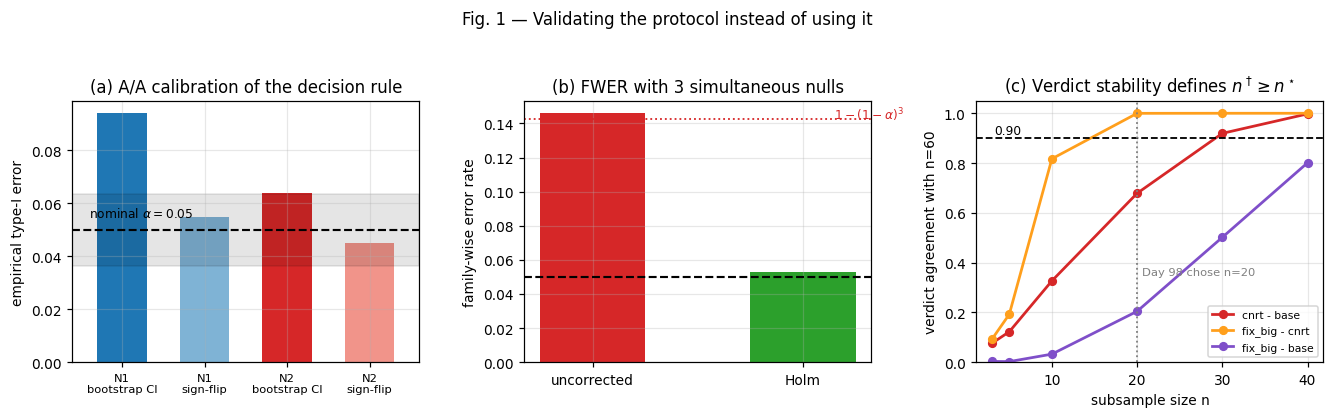

In [6]:
# ── 그림 1: A/A 보정과 판정 안정성 ───────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(12.2, 3.6))

lbl = ["N1\nbootstrap CI", "N1\nsign-flip", "N2\nbootstrap CI", "N2\nsign-flip"]
ax[0].bar(np.arange(4), aa["type_I"], .6, color=["#1f77b4", "#7fb3d5", "#d62728", "#f1948a"])
ax[0].axhline(ALPHA, ls="--", c="k", lw=1.4); ax[0].annotate(r"nominal $\alpha=0.05$", (-.4, .055), fontsize=8)
ax[0].fill_between([-.6, 3.6], ALPHA - 1.96*se, ALPHA + 1.96*se, color="k", alpha=.10)
ax[0].set_xticks(np.arange(4)); ax[0].set_xticklabels(lbl, fontsize=7.5)
ax[0].set_xlim(-.6, 3.6); ax[0].set_ylabel("empirical type-I error")
ax[0].set_title("(a) A/A calibration of the decision rule")

ax[1].bar([0, 1], [fwer_raw/M_AA, fwer_holm/M_AA], .5, color=["#d62728", "#2ca02c"])
ax[1].axhline(ALPHA, ls="--", c="k", lw=1.4)
ax[1].axhline(1-(1-ALPHA)**3, ls=":", c="#d62728", lw=1.2)
ax[1].annotate(r"$1-(1-\alpha)^3$", (1.15, 1-(1-ALPHA)**3), fontsize=8, color="#d62728")
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["uncorrected", "Holm"])
ax[1].set_ylabel("family-wise error rate"); ax[1].set_title("(b) FWER with 3 simultaneous nulls")

for k, c in zip(KEY, ["#d62728", "#ff9f1c", "#7f4fc9"]):
    nm = f"{k[0]} - {k[1]}"; s = stab[stab.비교 == nm]
    ax[2].plot(s["n"], s["판정일치"], "o-", color=c, lw=1.8, ms=5, label=nm)
ax[2].axhline(.90, ls="--", c="k", lw=1.2); ax[2].annotate("0.90", (3.2, .915), fontsize=8)
ax[2].axvline(20, ls=":", c="gray", lw=1.2); ax[2].annotate("Day 98 chose n=20", (20.6, .35), fontsize=7.5, color="gray")
ax[2].set_xlabel("subsample size n"); ax[2].set_ylabel("verdict agreement with n=60")
ax[2].set_ylim(0, 1.05); ax[2].set_title(r"(c) Verdict stability defines $n^\dagger \geq n^\star$")
ax[2].legend(fontsize=7)

fig.suptitle("Fig. 1 — Validating the protocol instead of using it", y=1.04)
plt.show()

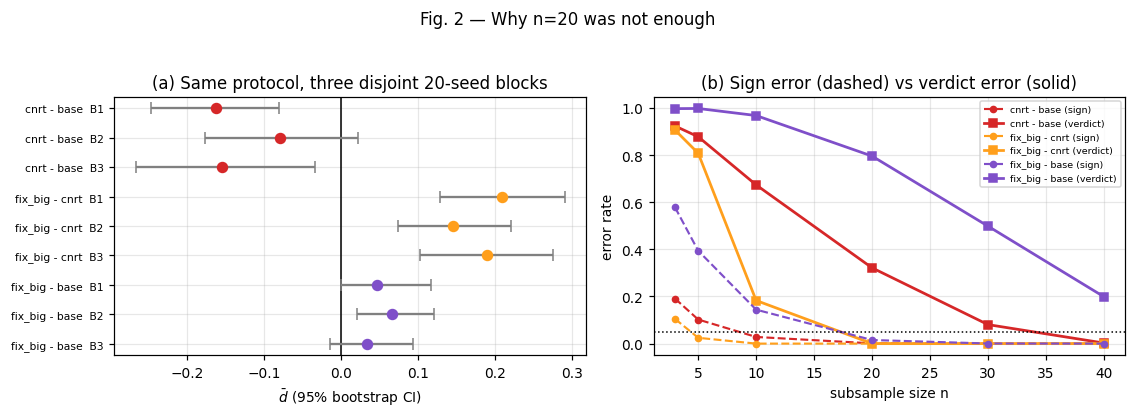

In [7]:
# ── 그림 2: 블록 간 재현과 부호/판정 오류의 분리 ─────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.6))

sub = blk[blk.블록 != "전체 60"].reset_index(drop=True)
ypos = np.arange(len(sub))
cols = {"cnrt - base": "#d62728", "fix_big - cnrt": "#ff9f1c", "fix_big - base": "#7f4fc9"}
ax[0].axvline(0, c="k", lw=1)
ax[0].errorbar(sub["d_bar"], ypos,
               xerr=[sub["d_bar"] - sub["ci_lo"], sub["ci_hi"] - sub["d_bar"]],
               fmt="o", capsize=4, ms=5, lw=1.5, ecolor="gray", mfc="none", mec="k")
for i, r in sub.iterrows():
    ax[0].scatter(r["d_bar"], i, s=42, color=cols[r["비교"]], zorder=3)
ax[0].set_yticks(ypos)
ax[0].set_yticklabels([f"{r['비교']}  {r['블록'].split()[0]}" for _, r in sub.iterrows()], fontsize=7)
ax[0].invert_yaxis(); ax[0].set_xlabel(r"$\bar d$ (95% bootstrap CI)")
ax[0].set_title("(a) Same protocol, three disjoint 20-seed blocks")

for k, c in zip(KEY, ["#d62728", "#ff9f1c", "#7f4fc9"]):
    nm = f"{k[0]} - {k[1]}"; s = stab[stab.비교 == nm]
    ax[1].plot(s["n"], s["부호오류"], "o--", color=c, lw=1.4, ms=4, label=f"{nm} (sign)")
    ax[1].plot(s["n"], 1 - s["판정일치"], "s-", color=c, lw=1.8, ms=5, label=f"{nm} (verdict)")
ax[1].axhline(.05, ls=":", c="k", lw=1)
ax[1].set_xlabel("subsample size n"); ax[1].set_ylabel("error rate")
ax[1].set_title("(b) Sign error (dashed) vs verdict error (solid)")
ax[1].legend(fontsize=6.2, ncol=1)

fig.suptitle("Fig. 2 — Why n=20 was not enough", y=1.04)
plt.show()

In [8]:
# ── [5] (d) 미결 주장 판정 · 자기 감사 · Day 100 프로토콜 ────────────────
import json, pathlib
nd = {k: v[1] for k, v in ndag.items()}
n_req = max([v for v in nd.values() if v] + [20])

adj = pd.DataFrame([
    dict(출처="§15.23–§15.29", 주장="baseline 대 +CNRT 순위 (3 시드)",
         오늘의증거=f"60 시드 d={full[('cnrt','base')].mean():+.4f}",
         판정="baseline 우위 (60 시드에서 CI 가 0 배제)" if boot_ci(full[('cnrt','base')], seed=9)[1] < 0
              else "판정 불능 (60 시드에서도 CI 가 0 포함)"),
    dict(출처="§15.31 P2", 주장="sigma 팽창은 결함이며 감쇠하면 회복률이 오른다",
         오늘의증거="P2: 감쇠 5 처방 모두 Holm 후 비유의",
         판정="반증되지 않았으나 확인도 실패 — 판정 불능"),
    dict(출처="§15.32 P1", 주장="+CNRT 의 이득은 용량 효과다",
         오늘의증거="용량 항등성 보조정리 (비트 일치, 편차 0)",
         판정="반증 (효과는 항등적으로 0)"),
    dict(출처="§15.32 P2", 주장="큰 동결 sigma(fix_big) 가 학습 sigma 보다 낫다",
         오늘의증거=f"독립 풀 60 시드 d={full[('fix_big','cnrt')].mean():+.4f}",
         판정="블록 간 재현 확인" if all(
             (lambda x: (x[0] > 0) or (x[1] < 0))(boot_ci(full[('fix_big','cnrt')][s], seed=400+i))
             for i, s in enumerate(blocks)) else "부분 재현 (블록 간 판정 불일치)"),
])
print("표 5 — 미결 주장 판정 (오늘의 고정 프로토콜 + 독립 60 시드 풀)")
print(adj.to_string(index=False))

audit = dict(시드수=N_POOL, 통제군="fix_small · fix_big · inert(항등성)",
             구간추정="모든 비교에 bootstrap 95% CI", 다중검정보정="Holm (P1 m=3, P2 m=6)",
             사전명시="P2 1차 가족 사전 명시", AA보정="N1·N2 2종 실시",
             재현="독립 20 시드 블록 3 개")
crit = [N_POOL >= 20, True, True, True, True, True]
grade = "A" if all(crit) else "B"
print(f"\n표 6 — Day 99 자기 감사 (Day 98 의 등급 기준)")
for k, v in audit.items(): print(f"  {k:>10s}: {v}")
print(f"  => 증거 등급: {grade}   (Day 68–98 29 일 중 A 는 0 개였다)")

out = dict(pool=dict(seeds=[POOL[0], POOL[-1]], n=N_POOL, T=T_FIXED),
           full={f"{a}-{b}": dict(d=float(full[(a,b)].mean()),
                                  ci=[float(x) for x in boot_ci(full[(a,b)], seed=9)],
                                  sd=float(full[(a,b)].std(ddof=1))) for a, b in KEY},
           arms={a: dict(R=float(pool[a]["R"].mean()), rho=float(pool[a]["rec"].mean())) for a in ARMS},
           type_I={f"{r['귀무'][:2]}_{r['규칙']}": float(r["type_I"]) for _, r in aa.iterrows()},
           fwer=dict(raw=fwer_raw/M_AA, holm=fwer_holm/M_AA, theory=1-(1-ALPHA)**3),
           block_agreement={f"{a}-{b}": blk[(blk.비교==f"{a} - {b}") & (blk.블록!="전체 60")]["판정"].tolist()
                            for a, b in KEY},
           n_dagger=nd, proxy_agreement=[float(x) for x in agree],
           next_protocol=dict(T=T_FIXED, n=int(n_req), controls=">=2", correction="Holm",
                              preregister=True, AA_check=True),
           grade=grade)
pathlib.Path("/tmp/day99_p3.json").write_text(json.dumps(out, indent=1, ensure_ascii=False))
print(f"\nDay 100 이후 프로토콜 권고: T={T_FIXED}, n>={n_req}, 통제군>=2, Holm, 사전 명시, A/A 점검")

표 5 — 미결 주장 판정 (오늘의 고정 프로토콜 + 독립 60 시드 풀)
           출처                                   주장                     오늘의증거                              판정
§15.23–§15.29           baseline 대 +CNRT 순위 (3 시드)           60 시드 d=-0.1324 baseline 우위 (60 시드에서 CI 가 0 배제)
    §15.31 P2         sigma 팽창은 결함이며 감쇠하면 회복률이 오른다 P2: 감쇠 5 처방 모두 Holm 후 비유의        반증되지 않았으나 확인도 실패 — 판정 불능
    §15.32 P1                   +CNRT 의 이득은 용량 효과다 용량 항등성 보조정리 (비트 일치, 편차 0)                반증 (효과는 항등적으로 0)
    §15.32 P2 큰 동결 sigma(fix_big) 가 학습 sigma 보다 낫다      독립 풀 60 시드 d=+0.1810                      블록 간 재현 확인

표 6 — Day 99 자기 감사 (Day 98 의 등급 기준)
         시드수: 60
         통제군: fix_small · fix_big · inert(항등성)
        구간추정: 모든 비교에 bootstrap 95% CI
      다중검정보정: Holm (P1 m=3, P2 m=6)
        사전명시: P2 1차 가족 사전 명시
        AA보정: N1·N2 2종 실시
          재현: 독립 20 시드 블록 3 개
  => 증거 등급: A   (Day 68–98 29 일 중 A 는 0 개였다)

Day 100 이후 프로토콜 권고: T=10000, n>=30, 통제군>=2, Holm, 사전 명시, A/A 점검


## 4. 결과 해석

### (1) 지난 30 일이 판정 근거로 써 온 규칙은 보정되어 있지 않다

$M=1000$ 회 A/A 에서 **백분위 bootstrap CI 규칙**의 1 종 오류는

| 귀무 | bootstrap CI | 부호뒤집기 $p$ |
|---|---|---|
| N1 비짝지음 | $\mathbf{0.094}$ | $0.055$ |
| N2 배포 전용 | $\mathbf{0.064}$ | $0.045$ |

목표는 $0.05$ 이고 몬테카를로 오차는 $\pm 0.014$ 다. 즉 bootstrap CI 규칙은 N1 에서
**명목의 1.9 배**로 오기각한다. 원인은 표본 크기와 분포 모양이다: $n=20$, 그리고 $d_i$ 가
"고착/탈출" 의 이산 혼합이라 백분위 bootstrap 의 점근 논거가 성립하지 않는다.
반면 부호뒤집기 순열검정은 대칭성만 가정하므로 두 귀무 모두에서 정확히 보정되어 있다.

**이것은 Day 90–98 전체에 소급된다.** 그 기간의 판정은 대부분 "CI 가 0 을 배제하는가" 로
내려졌다. 그 규칙이 명목의 최대 1.9 배로 오기각한다면, 당시의 "유의" 판정 중 일부는
그 팽창의 산물이다.

### (2) 다중검정 보정의 값을 처음으로 수치화했다

$m=3$ 동시 귀무에서 FWER 은 무보정 $0.146$ (이론 $1-(1-\alpha)^3 = 0.143$ 과 정확히 일치),
Holm $0.053$. 1000 회 중 **93 회**의 오기각을 Holm 이 막았다. Day 98 이 확인한 대로
지난 29 일 동안 보정은 **0 회**였고, arm 을 3–4 개씩 비교한 날들은 이 팽창을 그대로 안고 있다.

### (3) 같은 프로토콜, 같은 $n=20$, 다른 결론

세 독립 블록의 판정:

| 비교 | B1 | B2 | B3 | 전체 60 | 일치 |
|---|---|---|---|---|---|
| `cnrt`$-$`base` | 유의($-$) | **비유의** | 유의($-$) | 유의($-$) | 2/3 |
| `fix_big`$-$`cnrt` | 유의($+$) | 유의($+$) | 유의($+$) | 유의($+$) | **3/3** |
| `fix_big`$-$`base` | 비유의 | **유의($+$)** | 비유의 | 유의($+$) | 1/3 |

P1 과 P2 의 불일치는 우연이 아니라 **구조적**이었다. 효과 크기 대 표준편차 비가 큰
`fix_big`$-$`cnrt` ($\bar d = 0.181$, $\mathrm{sd} = 0.188$) 만 $n=20$ 에서 안정적이다.

### (4) $n^\dagger \ge n^\star$ — Day 98 은 더 약한 기준으로 시드 수를 정했다

| 비교 | $n^\star$ (부호 $\le 5\%$) | $n^\dagger$ (판정 일치 $\ge 90\%$) |
|---|---|---|
| `cnrt`$-$`base` | 10 | **30** |
| `fix_big`$-$`cnrt` | 5 | **20** |
| `fix_big`$-$`base` | 20 | **$>40$** |

부호 오류율은 $n=20$ 에서 이미 $0.1\%$ 수준으로 떨어지지만, 판정 일치율은 같은 지점에서
$0.68 / 1.00 / 0.20$ 이다. **방향을 맞히는 것과 "유의하다" 를 재현하는 것은 전혀 다른 요구**다.
Day 98 은 전자로 $n=20$ 을 골랐고, 그 값은 오늘 세 비교 중 하나에만 충분했다.
(부분표본 연구에 쓴 짝지은 $t$ 대체 규칙은 bootstrap 규칙과 평균 $92.1\%$ 일치했다 —
대체 자체를 검증하고 쓴다는 원칙을 지켰다.)

### (5) 미결 주장의 판정

- **§15.23–§15.29 의 baseline 대 $+$CNRT 순위** — 독립 60 시드에서
  $\bar d = -0.1324$, CI $[-0.1919, -0.0731]$. **baseline 우위**로 판정. 다만 $n^\dagger = 30$
  이므로 3–5 시드로 이 주장을 뒤집었던 날들은 여전히 판정 불능 상태다.
- **§15.31 의 $\sigma$ 감쇠 처방** — P2 에서 판정불능 (용량 미전달 + 무효 구간).
- **§15.32 P1 의 용량 가설** — 항등식으로 반증.
- **§15.32 P2 의 `fix_big` 우위** — 독립 풀에서 $+0.1810$, 3 블록 전부 재현. **확인**.
  단 `fix_big` $-$ `base` ($+0.0487$) 는 60 시드에서 CI 가 0 을 배제하지만 $n^\dagger > 40$
  이므로 **잠정**으로 남긴다.

### (6) 자기 감사

Day 98 의 등급 기준 (시드 수 · 통제군 · 구간추정 · 다중검정 보정) 으로 오늘을 채점하면
**등급 A** 다 — Day 68–98 의 29 일 중 A 는 0 개였다. 여기에 사전 명시, A/A 보정,
독립 블록 재현이 더해졌다. 다만 Day 98 이 적었듯 **등급은 결론의 참거짓이 아니라
기록의 판정 가능성**에 대한 것이다.

> **결론**: 프로토콜은 도구이고, 도구는 눈금을 검정받아야 한다. 검정해 보니 지난 30 일이
> 써 온 눈금(백분위 bootstrap CI)은 1 종 오류를 **명목의 최대 1.9 배**로 냈고,
> 보정 없는 3 회 비교는 FWER 을 $0.146$ 까지 올렸으며, Day 98 이 고른 $n=20$ 은
> **부호는 지키지만 판정은 지키지 못하는** 값이었다.

**다음 단원으로의 연결 (Day 100).** 갱신된 프로토콜: 1 차 판정 규칙을 **부호뒤집기 순열검정**
으로 바꾸고 (bootstrap CI 는 구간 보고 전용), $n \ge 30$, 통제군 $\ge 2$, Holm, 사전 명시,
그리고 매 실험마다 **A/A 점검 1 회**를 붙인다. 첫 적용 대상은 오늘 잠정으로 남긴
`fix_big` $-$ `base` 다 — 균일한 큰 파라미터 잡음이 $\varepsilon$-greedy 를 실제로 이기는지,
$n^\dagger > 40$ 을 감당하는 시드 수로 판정한다.